In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
class LogisticRegression:

    def __init__(self):
        self.w = None
        self.losses = []
    
    def log_loss(self, w, X, y):
        b = np.dot(X, w)
        sigma = 1 / (1 + np.exp(-b))
        
        epsilon = 1e-12
        sigma = np.clip(sigma, epsilon, 1 - epsilon)
        
        loss = -np.sum(y * np.log(sigma) + (1 - y) * np.log(1 - sigma))
        grad = np.dot(X.T, (sigma - y))
        
        return loss, grad
    
    def optimize(self, w, X, y, n_iterations, eta):
        self.w = np.copy(w)
        self.losses = []
        
        for i in range(n_iterations):
            loss, grad = self.log_loss(self.w, X, y)
            self.w -= eta * grad
            self.losses.append(loss)
        
        return self.w, self.losses
    
    def predict(self, X, threshold=0.5):
        b = np.dot(X, self.w)
        sigma = 1 / (1 + np.exp(-b))

        return (sigma > threshold).astype(int)

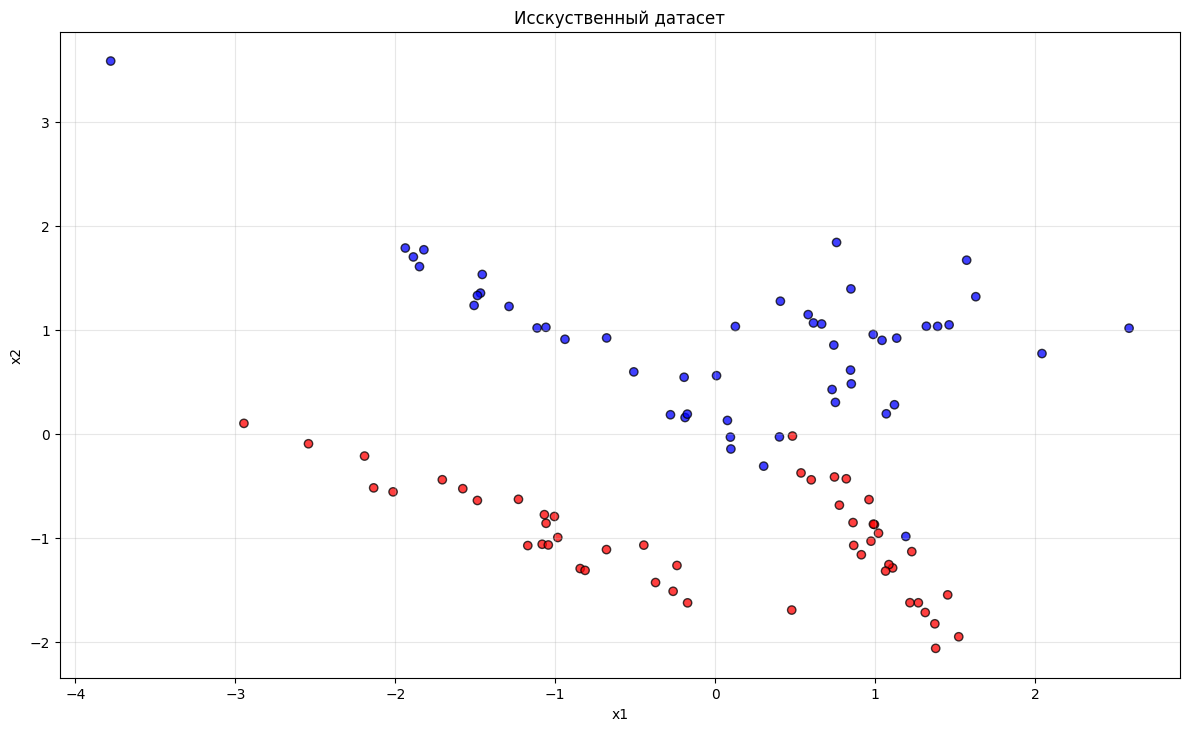

In [4]:

from sklearn import datasets
from matplotlib.colors import ListedColormap

classes = datasets.make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_classes=2, random_state=83)

colors = ListedColormap(['red', 'blue'])

X = classes[0]
y = classes[1]

plt.figure(figsize=(12, 12/1.618))

plt.title("Исскуственный датасет")
plt.xlabel("x1")
plt.ylabel("x2")

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=colors, alpha=0.75, edgecolor="k")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:

np.random.seed(83)
shuffle_index = np.random.permutation(classes[0].shape[0])
X_shuffled, y_shuffled = classes[0][shuffle_index], classes[1][shuffle_index]

train_proportion = 0.7
train_test_cut = int(len(classes[0]) * train_proportion)

X_train, X_test, y_train, y_test = \
    X_shuffled[:train_test_cut], \
    X_shuffled[train_test_cut:], \
    y_shuffled[:train_test_cut], \
    y_shuffled[train_test_cut:]

In [6]:
X_train_with_bias = np.column_stack([np.ones(X_train.shape[0]), X_train])
X_test_with_bias = np.column_stack([np.ones(X_test.shape[0]), X_test])

In [7]:
model = LogisticRegression()

w0 = np.zeros(X_train_with_bias.shape[1])
print(f"Форма w0 = {w0.shape}")

n_iterations = 100
eta = 0.05

w, losses = model.optimize(w0, X_train_with_bias, y_train, n_iterations, eta)

y_predicted_test = model.predict(X_test_with_bias)
y_predicted_train = model.predict(X_train_with_bias)

train_accuracy = np.mean(y_predicted_train == y_train) * 100
test_accuracy = np.mean(y_predicted_test == y_test) * 100

print(f"Итоговый вектор весов w: {w}")
print(f"Точность на обучающей выборке: {train_accuracy:.3f}%")
print(f"Точность на тестовой выборке: {test_accuracy:.3f}%")

Форма w0 = (3,)
Итоговый вектор весов w: [1.24141408 1.44152979 5.30213509]
Точность на обучающей выборке: 94.286%
Точность на тестовой выборке: 96.667%


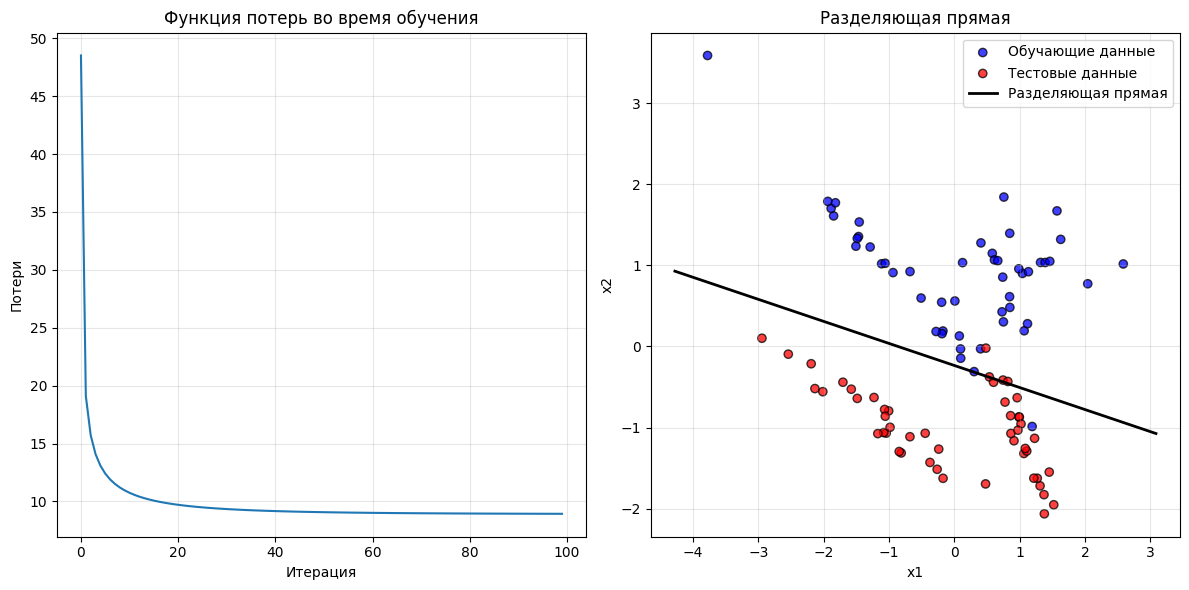

In [8]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Функция потерь во время обучения")
plt.xlabel("Итерация")
plt.ylabel("Потери")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=colors, alpha=0.75, label="Обучающие данные", edgecolors="k")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=colors, alpha=0.75, label="Тестовые данные", edgecolors="k")

# Уравнение: w0 + w1*x1 + w2*x2 = 0 => x2 = (-w0 - w1*x1) / w2
x_min, x_max = X_shuffled[:, 0].min() - 0.5, X_shuffled[:, 0].max() + 0.5
x1_vals = np.linspace(x_min, x_max, 100)
x2_vals = (-w[0] - w[1] * x1_vals) / w[2]

plt.plot(x1_vals, x2_vals, "k-", linewidth=2, label="Разделяющая прямая")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Разделяющая прямая")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()